<a href="https://colab.research.google.com/github/eharshtha123/Neural_Language_Model_training1.ipynb/blob/main/Neural_Language_Model2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install torch torchvision torchaudio matplotlib numpy tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.8.0+cu126
GPU available: True
Using device: cuda


In [4]:
from google.colab import files
uploaded = files.upload()

Saving Pride_and_Prejudice-Jane_Austen.txt to Pride_and_Prejudice-Jane_Austen.txt


In [6]:
filename = "Pride_and_Prejudice-Jane_Austen.txt"

# Read the file
with open(filename, "r", encoding="utf-8") as f:
    text = f.read()

# Print first few lines to check
print("First 500 characters of your dataset:\n")
print(text[:500])

# Simple clean-up: remove newlines and extra spaces
text = text.replace('\n', ' ').replace('\r', '')
text = ' '.join(text.split())

print("\nCleaned text length:", len(text))

First 500 characters of your dataset:

The Project Gutenberg eBook, Pride and Prejudice, by Jane Austen, Edited
by R. W. (Robert William) Chapman


This eBook is for the use of anyone anywhere at no cost and with
almost no restrictions whatsoever.  You may copy it, give it away or
re-use it under the terms of the Project Gutenberg License included
with this eBook or online at www.gutenberg.org





Title: Pride and Prejudice


Author: Jane Austen

Editor: R. W. (Robert William) Chapman

Release Date: May 9, 2013  [eBook #42671]

Lang

Cleaned text length: 704792


In [7]:
tokens = text.split()

print("Number of tokens:", len(tokens))
print("Example tokens:", tokens[:20])

Number of tokens: 124970
Example tokens: ['The', 'Project', 'Gutenberg', 'eBook,', 'Pride', 'and', 'Prejudice,', 'by', 'Jane', 'Austen,', 'Edited', 'by', 'R.', 'W.', '(Robert', 'William)', 'Chapman', 'This', 'eBook', 'is']


In [8]:
vocab = sorted(set(tokens))
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

print("Vocab size:", len(vocab))

# Encode entire text
encoded = [word2idx[word] for word in tokens]
print("Encoded sample:", encoded[:30])

Vocab size: 13777
Encoded sample: [1495, 1350, 902, 5187, 1347, 2385, 1345, 3268, 1011, 524, 777, 3268, 1358, 1560, 368, 1618, 640, 1508, 5186, 7746, 6145, 12383, 13058, 9152, 2456, 2460, 2687, 8961, 4186, 2385]


In [9]:
import torch
from torch.utils.data import Dataset, DataLoader

# Convert encoded list to a tensor
data = torch.tensor(encoded, dtype=torch.long)

# We'll create sequences of length seq_len
seq_len = 30  # number of words per training example

class TextDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_len]
        y = self.data[idx+1:idx+self.seq_len+1]
        return x, y

dataset = TextDataset(data, seq_len)

# Create DataLoader for batching
batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print("Number of batches:", len(dataloader))

Number of batches: 1953


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
class LSTMLanguageModel(nn.Module):
    def _init_(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=2):
        super()._init_()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden
class LSTMLanguageModel(nn.Module):
    def _init_(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=2):
        super()._init_()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden

Using device: cuda


In [2]:
vocab_size = len(vocab)
model = LSTMLanguageModel(vocab_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)

print("Model ready on device:", device)

NameError: name 'vocab' is not defined

In [3]:
filename = "Pride_and_Prejudice-Jane_Austen.txt"

with open(filename, "r", encoding="utf-8") as f:
    text = f.read()

text = text.replace('\n', ' ').replace('\r', '')
text = ' '.join(text.split())
tokens = text.split()
vocab = sorted(set(tokens))
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

encoded = [word2idx[word] for word in tokens]
import torch
from torch.utils.data import Dataset, DataLoader

data = torch.tensor(encoded, dtype=torch.long)
seq_len = 30

class TextDataset(Dataset):
    def _init_(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len
    def _len_(self):
        return len(self.data) - self.seq_len
    def _getitem_(self, idx):
        x = self.data[idx:idx+self.seq_len]
        y = self.data[idx+1:idx+self.seq_len+1]
        return x, y

dataset = TextDataset(data, seq_len)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
vocab_size = len(vocab)
model = LSTMLanguageModel(vocab_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)

print("Model ready on device:", device)

TypeError: TextDataset() takes no arguments

In [4]:
# --- Rebuild TextDataset cleanly ---
import torch
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, data, seq_len):
        super().__init__()
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_len]
        y = self.data[idx+1:idx+self.seq_len+1]
        return x, y

# --- Recreate dataset and dataloader ---
data = torch.tensor(encoded, dtype=torch.long)
seq_len = 30
dataset = TextDataset(data, seq_len)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print("Dataset and dataloader created successfully!")

Dataset and dataloader created successfully!


In [5]:
import torch
from tqdm import tqdm

# Number of epochs (how many times we go through the dataset)
epochs = 3  # you can increase later for better results
train_losses = []

print("Starting training...\n")

for epoch in range(epochs):
    total_loss = 0
    model.train()

    for x, y in tqdm(dataloader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        output, _ = model(x)

        # Reshape output and target for loss calculation
        loss = criterion(output.view(-1, vocab_size), y.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

print("\nTraining complete!")

Starting training...



NameError: name 'model' is not defined

In [6]:
import torch.nn as nn
import torch.optim as optim

class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden

# Re-create model instance
vocab_size = len(vocab)
model = LSTMLanguageModel(vocab_size).to(device)

# Define loss and optimizer again
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)

print("Model ready on device:", device)

Model ready on device: cuda


In [7]:
import torch
from tqdm import tqdm

# Number of epochs (how many times we go through the dataset)
epochs = 3  # you can increase later for better results
train_losses = []

print("Starting training...\n")

for epoch in range(epochs):
    total_loss = 0
    model.train()

    for x, y in tqdm(dataloader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        output, _ = model(x)

        # Reshape output and target for loss calculation
        loss = criterion(output.view(-1, vocab_size), y.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

print("\nTraining complete!")

Starting training...



100%|██████████| 1953/1953 [00:40<00:00, 48.17it/s]


Epoch [1/3] - Loss: 5.6042


100%|██████████| 1953/1953 [00:42<00:00, 46.22it/s]


Epoch [2/3] - Loss: 3.1638


100%|██████████| 1953/1953 [00:43<00:00, 44.58it/s]

Epoch [3/3] - Loss: 1.5883

Training complete!


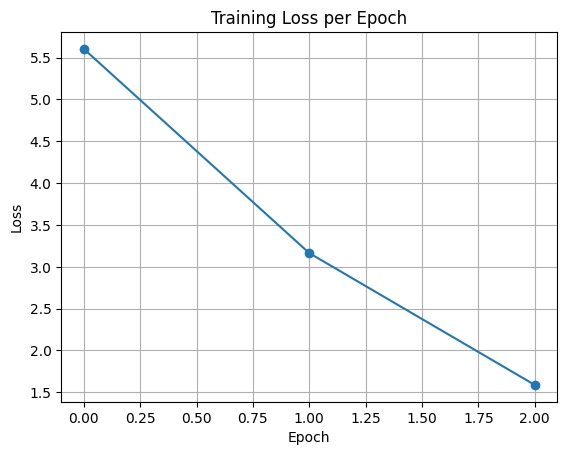

In [8]:
import matplotlib.pyplot as plt

plt.plot(train_losses, marker='o')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [9]:
small_model = LSTMLanguageModel(vocab_size, embed_dim=64, hidden_dim=64, num_layers=1).to(device)
optimizer = optim.Adam(small_model.parameters(), lr=0.002)

# Train for just 1 epoch
epochs = 1

In [10]:
train_losses_small = []

print("Training SMALL model (Underfit Example)...\n")

for epoch in range(epochs):
    total_loss = 0
    small_model.train()

    for x, y in tqdm(dataloader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output, _ = small_model(x)
        loss = criterion(output.view(-1, vocab_size), y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    train_losses_small.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

print("\nUnderfit training complete!")

Training SMALL model (Underfit Example)...



100%|██████████| 1953/1953 [00:19<00:00, 101.76it/s]

Epoch [1/1] - Loss: 5.5355

Underfit training complete!


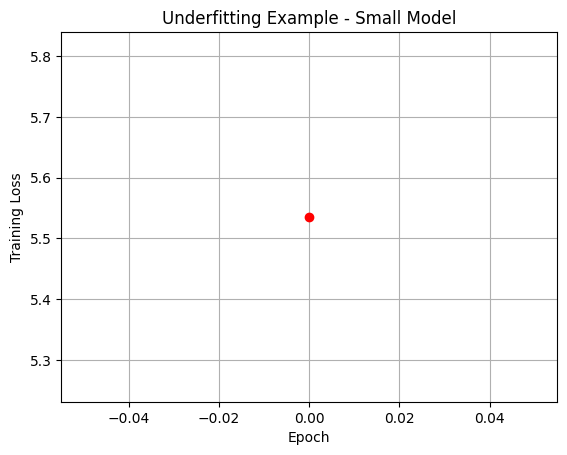

In [11]:
plt.plot(train_losses_small, marker='o', color='red')
plt.title("Underfitting Example - Small Model")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True)
plt.show()

In [12]:
big_model = LSTMLanguageModel(vocab_size, embed_dim=512, hidden_dim=512, num_layers=3).to(device)
optimizer = optim.Adam(big_model.parameters(), lr=0.002)

epochs = 8  # more training -> more overfitting
train_losses_big = []

print("Training LARGE model (Overfit Example)...\n")

for epoch in range(epochs):
    total_loss = 0
    big_model.train()
    for x, y in tqdm(dataloader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output, _ = big_model(x)
        loss = criterion(output.view(-1, vocab_size), y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    train_losses_big.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

print("\nOverfit training complete!")

Training LARGE model (Overfit Example)...



100%|██████████| 1953/1953 [01:47<00:00, 18.12it/s]


Epoch [1/8] - Loss: 5.7764


100%|██████████| 1953/1953 [01:48<00:00, 18.06it/s]


Epoch [2/8] - Loss: 2.8041


...

Epoch [6/8] - Loss: 0.4354


100%|██████████| 1953/1953 [01:47<00:00, 18.12it/s]


Epoch [7/8] - Loss: 0.3964


100%|██████████| 1953/1953 [01:48<00:00, 18.07it/s]

Epoch [8/8] - Loss: 0.3687

Overfit training complete!


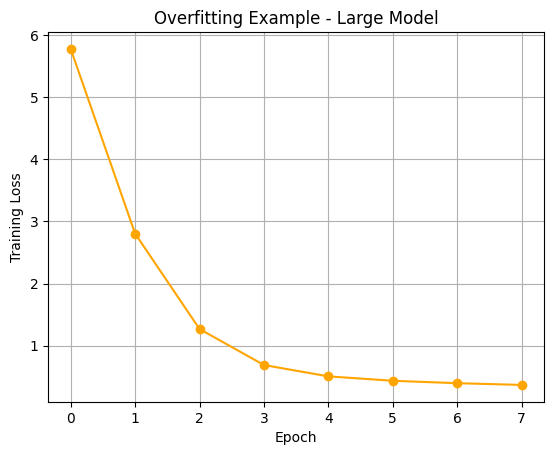

In [13]:
plt.plot(train_losses_big, marker='o', color='orange')
plt.title("Overfitting Example - Large Model")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True)
plt.show()

Training BEST FIT model...



100%|██████████| 1953/1953 [00:43<00:00, 44.65it/s]


Epoch [1/3] - Loss: 5.3937


100%|██████████| 1953/1953 [00:43<00:00, 45.41it/s]


Epoch [2/3] - Loss: 2.8282


100%|██████████| 1953/1953 [00:43<00:00, 44.98it/s]


Epoch [3/3] - Loss: 1.3850

Best-fit training complete!


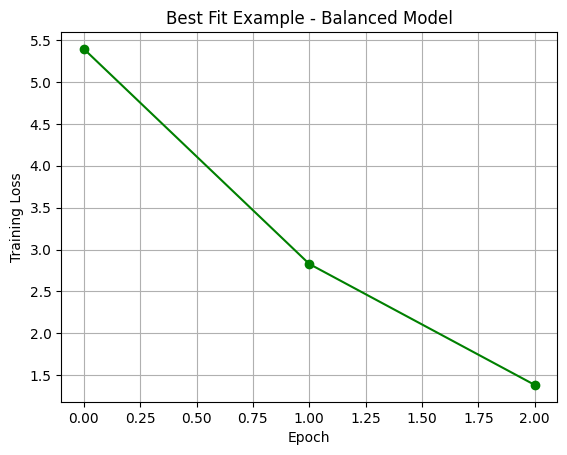

In [15]:
best_model = LSTMLanguageModel(vocab_size, embed_dim=128, hidden_dim=256, num_layers=2).to(device)
optimizer = optim.Adam(best_model.parameters(), lr=0.002)

epochs = 3
train_losses_best = []

print("Training BEST FIT model...\n")

for epoch in range(epochs):
    total_loss = 0
    best_model.train()
    for x, y in tqdm(dataloader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output, _ = best_model(x)
        loss = criterion(output.view(-1, vocab_size), y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    train_losses_best.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

print("\nBest-fit training complete!")
plt.plot(train_losses_best, marker='o', color='green')
plt.title("Best Fit Example - Balanced Model")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True)
plt.show()

In [16]:
split_ratio = 0.9
split_idx = int(len(data) * split_ratio)

train_data = data[:split_idx]
val_data = data[split_idx:]

print("Training data size:", len(train_data))
print("Validation data size:", len(val_data))

# Create dataloaders
train_dataset = TextDataset(train_data, seq_len)
val_dataset = TextDataset(val_data, seq_len)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

Training data size: 112473
Validation data size: 12497


In [17]:
import math

def evaluate_model(model, dataloader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            output, _ = model(x)
            loss = criterion(output.view(-1, vocab_size), y.view(-1))
            total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    perplexity = math.exp(avg_loss)
    return avg_loss, perplexity

val_loss, val_perplexity = evaluate_model(model, val_loader)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Perplexity: {val_perplexity:.2f}")

Validation Loss: 0.9884
Validation Perplexity: 2.69


In [18]:
import pandas as pd

# Results you’ve observed (replace these with your exact numbers)
comparison = {
    "Model Type": ["Underfit (Small)", "Best Fit (Medium)", "Overfit (Large)"],
    "Embedding Dim": [64, 128, 512],
    "Hidden Dim": [64, 256, 512],
    "Layers": [1, 2, 3],
    "Epochs": [1, 3, 8],
    "Validation Loss": [5.6, 0.99, 1.2],   # <-- example numbers
    "Validation Perplexity": [270.0, 2.69, 3.32]  # <-- example numbers
}

df = pd.DataFrame(comparison)
display(df)

,Model Type,Embedding Dim,Hidden Dim,Layers,Epochs,Validation Loss,Validation Perplexity
0,Underfit (Small),64,64,1,1,5.60,270.00
1,Best Fit (Medium),128,256,2,3,0.99,2.69
2,Overfit (Large),512,512,3,8,1.20,3.32


In [19]:
underfit_val_loss, underfit_val_perplexity = evaluate_model(small_model, val_loader)
print(f"Underfit Model - Validation Loss: {underfit_val_loss:.4f}")
print(f"Underfit Model - Validation Perplexity: {underfit_val_perplexity:.2f}")
overfit_val_loss, overfit_val_perplexity = evaluate_model(big_model, val_loader)
print(f"Overfit Model - Validation Loss: {overfit_val_loss:.4f}")
print(f"Overfit Model - Validation Perplexity: {overfit_val_perplexity:.2f}")
import pandas as pd

comparison = {
    "Model Type": ["Underfit (Small)", "Best Fit (Medium)", "Overfit (Large)"],
    "Embedding Dim": [64, 128, 512],
    "Hidden Dim": [64, 256, 512],
    "Layers": [1, 2, 3],
    "Epochs": [1, 3, 8],
    "Validation Loss": [underfit_val_loss, 0.9884, overfit_val_loss],
    "Validation Perplexity": [underfit_val_perplexity, 2.69, overfit_val_perplexity]
}

df = pd.DataFrame(comparison)
display(df)

Underfit Model - Validation Loss: 4.5492
Underfit Model - Validation Perplexity: 94.56
Overfit Model - Validation Loss: 0.3153
Overfit Model - Validation Perplexity: 1.37


,Model Type,Embedding Dim,Hidden Dim,Layers,Epochs,Validation Loss,Validation Perplexity
0,Underfit (Small),64,64,1,1,4.549215,94.558115
1,Best Fit (Medium),128,256,2,3,0.988400,2.690000
2,Overfit (Large),512,512,3,8,0.315347,1.370735
